# Oppgave 4

In [2]:
#Importerer nødvendige biblioteker
import numpy as np
import matplotlib.pyplot as plt
import scipy
import random
import math

#Setter opp plotteparametere
plt.rcParams['figure.figsize'] = [12, 8]  # Width, Height in inches


# Sannsynlighetstettheter for steg til høyre, venstre og ingen steg.
def p_plus(x, V, beta):
    return 1/(1+np.exp(-np.clip(beta*(V(x-h)-V(x+h)), -500, 500)) + np.exp(-np.clip(beta*(V(x)-V(x+h)), -500, 500)))

def p_null(x, V, beta):
    return 1/(1+np.exp(-np.clip(beta*(V(x-h)-V(x)), -500, 500)) + np.exp(-np.clip(beta*(V(x+h)-V(x)), -500, 500)))

def p_minus(x, V, beta):
    return 1/(1+np.exp(-np.clip(beta*(V(x+h)-V(x-h)), -500, 500)) + np.exp(-np.clip(beta*(V(x)-V(x-h)), -500, 500)))

beta = 1000                     # Beta-parameteren for at potensialet skal dominere sannsynlighetstettetene
delta_t = 1                     # Lengde på tidssteg
h = 1                           # Steglengde
timeCycle = 75                  # Antall tidssykluser
number_of_particles = 3         # Antall partikler
N_x = 100                       # Lengde på den romlige perioden til potensialet
T_p = 200                       # Antall tidssteg i en tidssyklus
k_even = 1                      # Konstant for det konstante potensialet
k_odd = 1                       # Konstant for sagtann-potensialet
alpha = 0.1                     # Parameter for sagtann potensialet
bin_size = int(2* np.cbrt(N_x)) # Antall bins i histogrammet

# Konstant potensial
def V_even(x, alpha):
    return k_even

# Sagtann-potensial
def V_odd(x, alpha):
    x_mod = x % N_x
    if x_mod < alpha * N_x:
        return k_odd * x_mod / np.clip(alpha * N_x, 1e-10, None)
    else:
        return k_odd * (N_x - x_mod) / np.clip((1 - alpha) * N_x, 1e-10, None)


# Funksjon for random walk simulasjon i alternerende potensial
def sim2(T_p, N_x, x_start, alpha):
    x = np.zeros((2*timeCycle, number_of_particles))
    x[0] = x_start
    X = x.copy() # Array med posisjonene til partiklene uten at de looper rundt
    X_cycle = np.zeros((timeCycle, number_of_particles)) # Array for å lagre posisjonene til partiklene for hver tidssyklus
    J = np.zeros(2*timeCycle*T_p) # Array for å lagre bevegelsesstrømmen for hvert tidssteg for hver tidssyklus
    for k in (range(0, 2*timeCycle, delta_t)):
        if k % 2 == 0:  # For å kjøre igjennom begge potensialene hver tidssyklus
            V = lambda x: V_even(x, alpha)
        else:
            V = lambda x: V_odd(x, alpha)

        for i in (range(0, T_p, delta_t)):
            previous_X = np.zeros(number_of_particles)
            for j in (range(number_of_particles)):
                a = random.uniform(0, 1) # Trekker fra std norm fordeling og flytter partikkel tilsvarende
                previous_X[j] = X[k][j]

                if a <= p_minus(x[k][j], V, beta):
                    x[k][j] -= h
                elif (1 - p_plus(x[k][j], V, beta)) < a:
                    x[k][j] += h

                if (1 - p_plus(X[k][j], V, beta)) < a:
                    X[k][j] += h 
                elif a <= p_minus(X[k][j], V, beta):
                    X[k][j] -= h 

                if x[k][j]  == -N_x -h:
                    x[k][j] = N_x
                elif x[k][j] == N_x + h:
                    x[k][j] = -N_x

                if j == number_of_particles - 1:
                    J[T_p*k+i] = np.mean(X[k] - previous_X)

                if i == T_p - delta_t and k != 2*timeCycle - delta_t:
                    x[k+1][j] = x[k][j]
                    X[k+1][j] = X[k][j]
                    
    #Finner gjennomsnittlig bevegelsesstrøm for hver tidssyklus                    
    J_avg = np.zeros(timeCycle)
    for i in range(timeCycle):
        J_avg[i] = np.mean(J[i*2*T_p:(i+1)*2*T_p])

    for i in range(timeCycle):
        for j in range(number_of_particles):
            X_cycle[i, j] = X[2*i+1][j]

    return x, X, X_cycle, J, J_avg
    


# a)

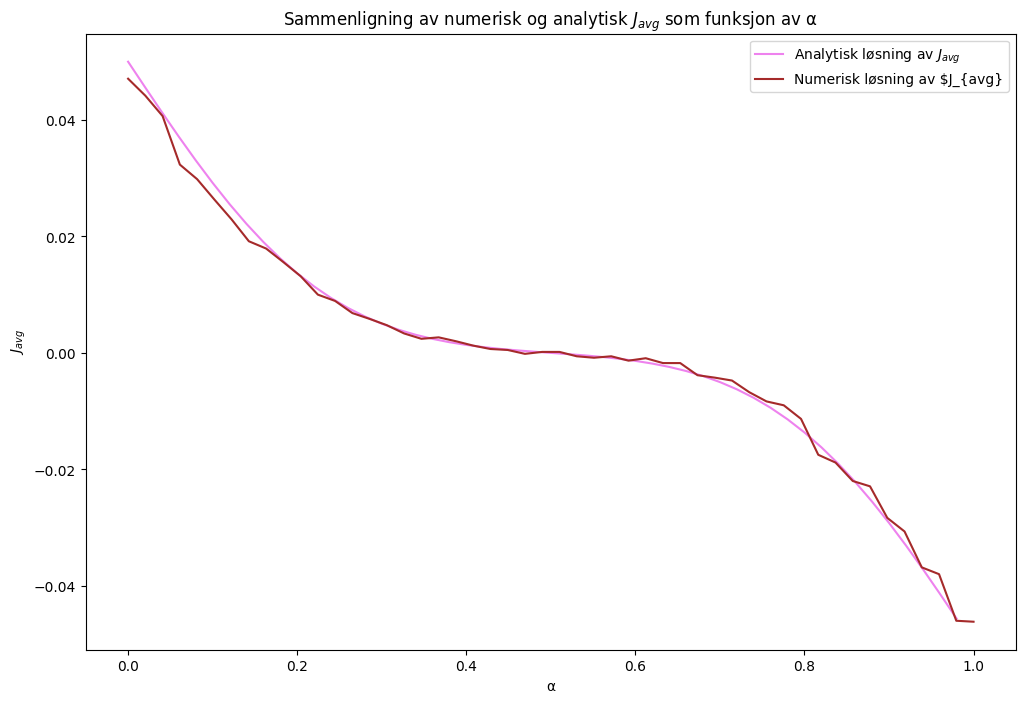

In [3]:
# Kode hentet fra 3d: 

T_p = 500                       # Antall tidssteg i en tidssyklus
N_x = 100                       # Lengde på den romlige perioden til potensialet
number_of_particles = 12*N_x    # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # Antall tidssykluser
h = 1                           # Steglengde

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))])

alpha_array = np.linspace(0, 1, 50)

J_avg_all_alpha2 = []
for alf in (alpha_array):
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha=alf)
    J_avg_all_alpha2.append(J_avg4[0])


D = 1/3
T_p = 500
N_x_analytic = 100
alphaArray = np.arange(0, 1, 1/50)

def J_avg(alpha, T_p, N_x):     # Definerer funksjon for analytisk løsning av gjennomsnittlig partikkelstrøm per tidssteg
    J = (N_x/(4*T_p))*(math.erfc((alpha*N_x/2)*np.sqrt(3/T_p)) - math.erfc(((1-alpha)*N_x/2)*np.sqrt(3/T_p)))
    return J

J_analytic = []                 # Oppretter liste som skal fylles med J_avg for forskjellige alpha-verdier
for alphaValues in alphaArray:  # Itererer gjennom alle alpha-verdiene
    J_analytic.append(J_avg(alphaValues, T_p, N_x_analytic))    

plt.plot(alphaArray, N_x/N_x_analytic * np.array(J_analytic), label = 'Analytisk løsning av $J_{avg}$', color = 'violet')
plt.plot(alpha_array, J_avg_all_alpha2, label = 'Numerisk løsning av $J_{avg}', color = 'brown')
plt.title('Sammenligning av numerisk og analytisk $J_{avg}$ som funksjon av α')
plt.xlabel('α')
plt.ylabel('$J_{avg}$')
plt.legend()
plt.show()

Grafen viser analytisk $J_{avg}$ sammenlignet med simuleringen fra oppgave 3 d) når $T_p = 500$. 
Ved lave α ser vi en tydelig tendens til at $J_{avg}$ er positiv, altså at den gjennomsnittlige partikkelstrømmen går mot høyre. 
Ved høye α ser vi tilsvarende en tendens til at $J_{avg}$ er negativ, altså at den gjennomsnittlige partikkelstrømmen går mot høyre. 
Ved midten ser vi ingen tydelig trend. 

Under følger tre plot av sagtann-potensialet ved ulike α som gjør det lettere å forklare tendensene over.

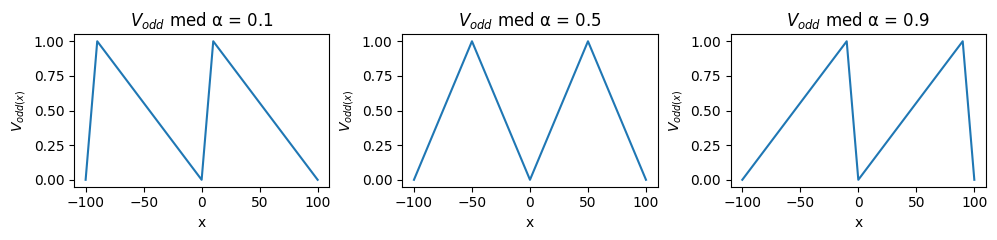

In [4]:
fig, axs = plt.subplots(1, 3, figsize=(10, 2.5))

alphas = [0.1, 0.5, 0.9]
x_values = np.arange(-N_x, N_x+1)

for i, alpha in enumerate(alphas):
    axs[i].plot(x_values, [V_odd(x, alpha) for x in x_values])
    axs[i].set_title(f'$V_{{odd}}$ med α = {alpha}')
    axs[i].set_xlabel('x')
    axs[i].set_ylabel('$V_{odd(x)}$')

plt.tight_layout()
plt.show()


Partiklenes gjennomsnittlige bevegelsesstrøm vil variere avhengig av hvordan sagtann-potensialet ser ut. 
Hver tidssyklus vil starte med at partiklene befinner seg i konstant potensial. Da vil partiklene "virrevandre" og kunne bevege seg både til høyre, venstre og bli værende, såkalt "random walk". Etter $T_p$ antall tidssteg vil potensialet bytte til et sagtann-potensial. 

Dersom alfa-verdiene i sagtann-potensialet er mellom $0.0$ og $0.3$ (slik som figuren til venstre), vil partiklene tendere mot å bevege seg til høyre, fordi det vil kreve for mye energi å bevege seg mot venstre. Når er ny syklus begynner og potensialet blir konstant, vil partiklene fortsette virrevandringen. Da må partiklene forflytte seg en lengre distanse for å passere posisjonen til toppunktet til sagtannen til venstre, og det blir lite bevegelsesstrøm mot venstre. 

Dersom alfa-verdiene i sagtann-potensialet er mellom $0.7$ 0g $1.0$ (slik som i figuren til høyre), vil partiklene tendere mot å bevege seg til venstre, med tilsvarende argumentasjon som over.

Dersom alfa-verdien er omtrent $0.5$, ser vi at sagtennene har lik avstand mellom toppunktene. Dette fører til at gjennomsnittlig bevegelsesstrøm vil være omtrent $0$, da det vil være like sannsynlig for partiklene å bevege seg i begge retninger. 

Disse tendensene er tydelige i sammenligningen av $J_{avg}$ og simuleringen. Ved lave alfa-verdier er gjennomsnittlig bevegelsesstrøm positiv for både den numeriske og analytiske løsningen. Rundt $α = 0.5$ holder bevegelsesstrømmen seg rundt $0$ i begge tilfeller, og ved høye alfa-verdier er gjennomsnittlig bevegelsestrøm negativ. 

Avvikene mellom den numeriske og analytiske løsningen kommer av tilfeldighetene som spiller inn i simuleringen av partiklene. 
Den analytiske løsningen antar en perfekt normalfordeling av partiklene. Dersom det hadde vært mulig å simulere et uendelig antall partikler ville deres posisjon i det konstante potensialet gått mot en normalfordeling. Siden dette ikke er mulig vil tilfeldighetene i virrevandringen påvirke bevegelsesstrømmen, og det oppstår avvik mellom de to løsningene. Vi ser alllikevel at tendensene er like.

# b)

In [5]:
# Numerisk løsning av J_avg

alpha = 0.8                     # Setter alfa-verdien
N_x = 10                        # Lengde på den romlige perioden til sagtann-potensialet
number_of_particles = 40*N_x     # Med 12*N_x partikler vil det være 6 partikler for hvert heltall mellom -N_x og N_x
timeCycle = 1                   # Antall tidssykluser
h = 1                      # Steglengde

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))]) # Array med startposisjonene til partiklene

T_p = 80
T_p_array = []

X4_all_Tp = []                  
J_avg_all_Tp2 = []
for r in range(20):                 # Itererer gjennom 20 forskjellige Tp-verdier
    T_p_array.append(T_p)           # Fyller liste med 20 forskjellige Tp-verdier fra 80 til 1500
    x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alpha)
    J_avg_all_Tp2.append(J_avg4[0]) # Fyller liste med J_avg ved forskjellige Tp-verdier
    T_p += 71                       # Sørger for ny Tp-verdi ved neste iterasjon (sørger for heltall)

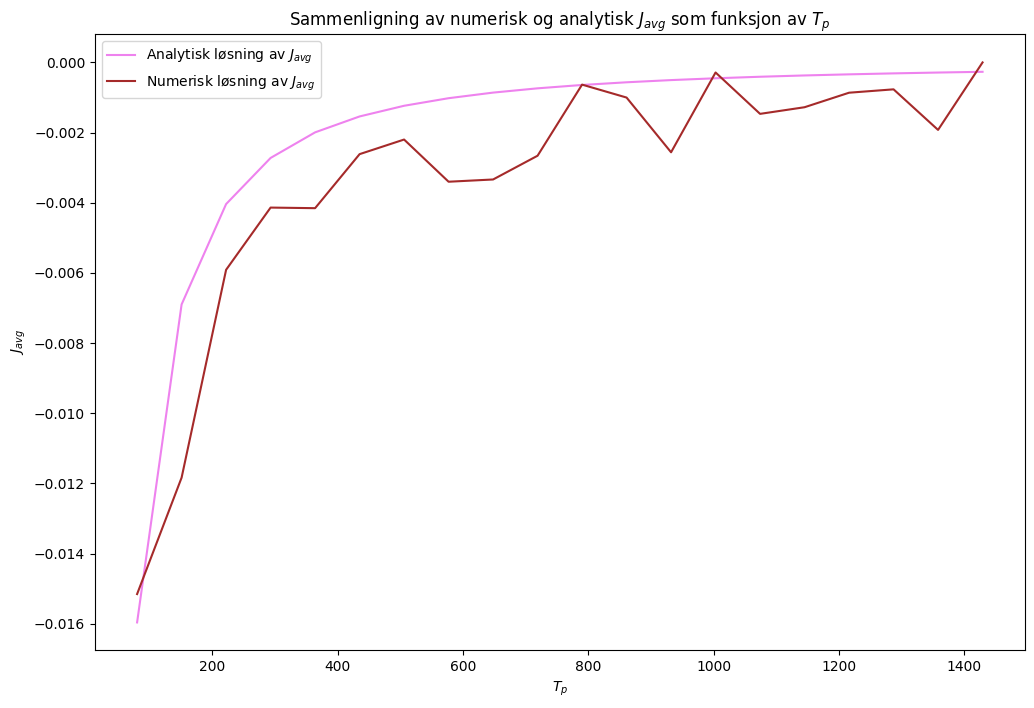

In [6]:
# Analytisk løsning av J_avg

D = 1/3                                 # Diffusjonskoeffisient
T_p = 80                                # Antall tidssteg i en tidssyklus
N_x_analytic = 10                     # Lengde på den romlige perioden til sagtann-potensialet

J_avg_analytic2 = []
for T_p_Values in T_p_array:                                        # Itererer gjennom 20 forskjellige Tp-verdier
    J_avg_analytic2.append(J_avg(alpha, T_p_Values, N_x_analytic))  # Fyller liste med J_avg ved forskjellige Tp-verdier

plt.plot(T_p_array, J_avg_analytic2, label = 'Analytisk løsning av $J_{avg}$', color = 'violet') 
plt.plot(T_p_array, J_avg_all_Tp2, label = 'Numerisk løsning av $J_{avg}$', color = 'brown')
plt.title('Sammenligning av numerisk og analytisk $J_{avg}$ som funksjon av $T_p$')
plt.xlabel('$T_p$')
plt.ylabel('$J_{avg}$')
plt.legend()
plt.show()

Begge løsningene i grafen over viser at $J_{avg}$ vil være negativ, altså at gjennomsnittsstrømmen til partiklene vil være mot venstre. 

I sagtann-potensialet i løsningene over er $α = 0.8$, altså vil toppunktene til sagtennene være langt til høyre. 
Når potensialet bytter til det konstante potensialet vil partikkelen "virrevandre". Selv hvis partikkelen virrevandrer mot høyre vil bevegelsesstrømmen registreres som 0 fordi partikkelen vil havne tilbake i potensialets minimum når det byttes til sagtann-potensialet. 
Dersom partikkelen virrevandrer mot venstre vil det derimot være svært sannsynlig at den befinner seg over den venstre sagtannen når potensialet bytter. I dette tilfellet vil bevegelsesstrømmen registreres som negativ.

Dette forklarer at gjennomsnittlig strøm av partikler vil være mot venstre, da det vil være mye mer sannsynlig at en partikkel har bevegd seg mot venstre i løpet av en tidssyklus.

For lave $T_p$ ser vi at gjennomsnittlig bevegelsesstrøm raskt blir mindre negativ. Dette er å forvente siden $N_x = 10$. En liten økning i antall tidssteg vil da gjøre det svært mye mer sannsynlig at en partikkel klarer å virrevandre til en posisjon som er over sagtannen til høyre når potensialet bytter. Når antall tidssteg blir mange ganger større enn lengden på perioden til sagtann-potensialet vil det dermed bli tilnærmet like sannsynlig at partikkelen flytter seg mot høyre som mot venstre. Dette ser vi ved at $J_{avg}$ går mot $0$ ved et stort antall tidssteg. Det at $α = 0.8$ medfører allikevel en svak tendens mot venstre, selv ved mange tidssteg. 

Også her observerer vi avvik mellom numerisk og analytisk løsning av $J_{avg}$. Som i plottet over skyldes også disse de tilfeldige utslagene som oppstår i simuleringen av "random walk". 

# c)

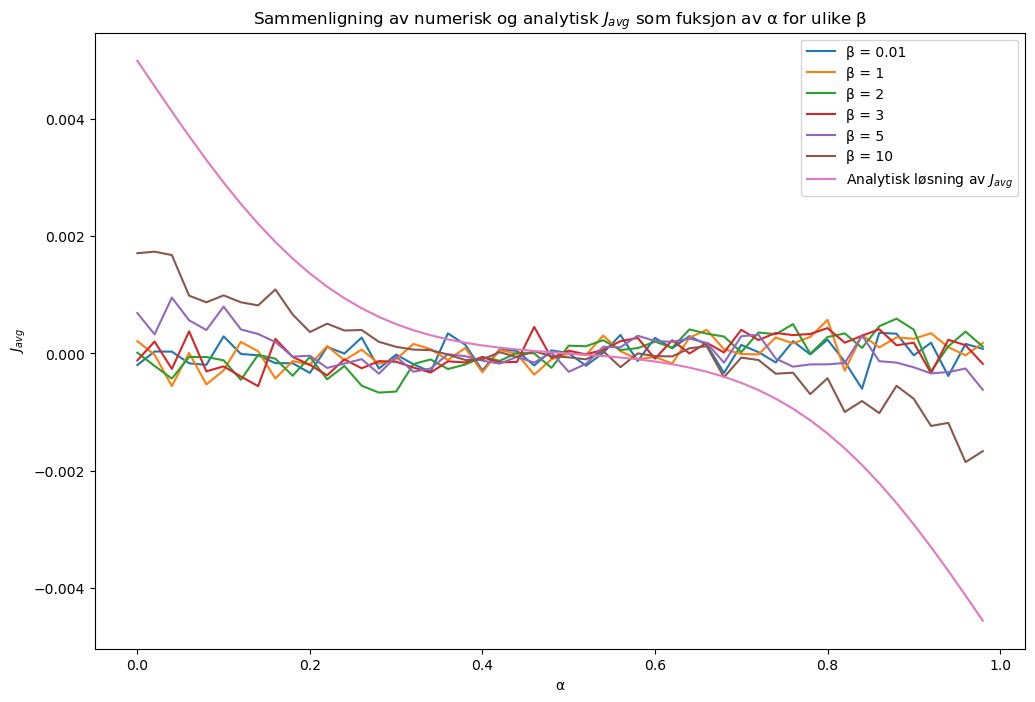

In [43]:
D = 1/3                                     # Diffusjonskoeffisient
T_p = 500                                   # Antall tidssteg i en tidssyklus
N_x_analytic = 100                          # Lengde på den romlige perioden til sagtann-potensialet
N_x = 10                                    
alphaArray = np.arange(0, 1, 1/50)          # Liste med jevnt fordelte alfa-verdier
BetaList = [0.01, 1, 2, 3, 5, 10]           # Liste med beta-verdier gitt i oppgaven
number_of_particles = 12*N_x
timeCycle = 1
h = N_x/100                                 # Steglengde

integers = np.arange(-N_x, N_x, N_x)
x_start = np.array([i for i in integers for _ in range(int(number_of_particles/2))])    # Array med startposisjonene til partiklene

for b in BetaList:                          # Itererer gjennom betaverdiene
    beta = b
    J_avg_all_alpha2 = []
    for alphaValue in alphaArray:           # Itererer gjennom alfaverdiene
        x4, X4, X_cycle4, J4, J_avg4 = sim2(T_p, N_x, x_start, alphaValue)              # Simulerer for gitt alfaverdi og gitt betaverdi
        J_avg_all_alpha2.append(J_avg4[0])                                              # Fyller liste med J_avg

    plt.plot(alphaArray, J_avg_all_alpha2, label = f"β = {beta}")                       # Plotter J_avg for gitt beta

J_avg_analytic3 = []
for alphaValue in alphaArray:
    J_avg_analytic3.append(J_avg(alphaValue, T_p, N_x_analytic))                        # Finner analytisk J_avg ved ulike alfa


plt.plot(alphaArray, N_x/N_x_analytic *np.array(J_avg_analytic3), label = "Analytisk løsning av $J_{avg}$")
plt.title('Sammenligning av numerisk og analytisk $J_{avg}$ som fuksjon av α for ulike β')
plt.xlabel('α')
plt.ylabel('$J_{avg}$')
plt.legend()
plt.show()

Den analytiske løsningen i grafen over viser, som før, at lave verdier for alfa vil gi gjennomsnittlig bevegelsesstrøm mot høyre, mens høye verider for alfa vil gi gjennomsnittlig bevegelsesstrøm mot venstre. 

Beta-verdiene brukt i simuleringen vil påvirke i hvor stor grad partikkelen påvirkes av sagtann-potensialet.
Siden $β = \frac {1}{k_b T}$, vil en lav verdi for $β$ tilsvare høy termisk energi. Da vil partiklene ha høy nok energi til å bevege seg uten påvirkning fra sagtann-potensialet, og det vil være like sannsynlig å bevege seg i alle begge retninger.
Da vil $J_{avg}$ holde seg rundt $0$, men vil variere noe som resultat av tilfeldig bevegelse.

En høy verdi for $β$ vil tilsvare lav termisk energi. Da vil partiklene ha så lav energi at de vil påvirkes av potensialforskjellene i sagtann-potensialet og ikke lenger bevege seg fritt. Det vil da være mer sannsynlig å bevege seg i noen retninger enn andre, avhengig av α-verdien til sagtann-potensialet. I disse tilfellene vil $J_{avg}$ følge samme tendens som den analytiske løsningen, og gi positive ferdier for små $α$ og negative verdier for store α.

Disse tendensene ser vi tydelig i grafen over. $J_{avg}$ for $β = {0.01, 1, 2, 3}$ holder seg forholdsvis nærme $0$.
For $β = 5$ og $β = 10$ ser vi derimot økende grad av påvirkning fra sagtann-potensialet. 

## d)

Den analytiske modellen antar at:
1) Alle partiklene sprer seg ut som en normalfordeling i det konstante potensialet.
2) Alle partiklene som har posisjon $x > \alpha N_x$ går til neste høyre minimum av sagtann-potensialet
3) Alle partiklene med posisjon $x < -(1-\alpha N_x)$ går til neste venstre minimum av sagtann-potensialet
4) Alle partiklene med posisjon $\alpha N_x > x > -(1-\alpha N_x)$ står i ro i det minimumet det startet i

Som man kan se i oppgave c), gjelder ikke dette når $\beta$ er liten. Da kan partiklene ha nok termisk energi for å bevege seg imot potensialet. Det er derfor ikke gitt at en partikkel går til neste minimum dersom potensialet "dytter" det dit. Når $\beta$ er lav "nok", er antagelsene ugyldige.
